# Personal Trading Performance Analysis

**Goal:** Analyse my real MT4 trade history to identify performance patterns, edge, and areas 
for improvement across EURUSD and GBPUSD.

**Dataset:** 65 closed trades across May–June 2026, including entry/exit prices, P&L, 
commission, volume, and exit reason.

**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

trades = pd.read_csv('../data/mt4_trade_history.csv')
trades.head()

,Position,Login,Symbol,Date,Action,Entry,Reason,Profit,Commission,Swap,Volume,VolumeClosed,Price,StopLoss,TakeProfit
0,92556557,2715093,GBPUSD,2026-05-18T10:25:35,Buy,In,Mobile,-2.50,-2.50,0.0,1.0,0.0,1.33470,NaN,NaN
1,92556557,2715093,GBPUSD,2026-05-18T11:09:44,Sell,Out,SL,47.50,-2.50,0.0,1.0,1.0,1.33520,1.33523,1.33771
2,92582541,2715093,EURUSD,2026-05-18T12:27:16,Sell,In,Mobile,-1.50,-1.50,0.0,0.6,0.0,1.16374,NaN,NaN
3,92582541,2715093,EURUSD,2026-05-18T14:34:35,Buy,Out,SL,-3.30,-1.50,0.0,0.6,0.6,1.16377,1.16371,1.16124
4,93222380,2715093,EURUSD,2026-05-21T10:55:20,Sell,In,Mobile,-1.25,-1.25,0.0,0.5,0.0,1.16061,NaN,NaN


In [2]:
# convert date to datetime
trades['Date'] = pd.to_datetime(trades['Date'])

# separate entry and exit legs
entries = trades[trades['Entry'] == 'In'].copy()
exits = trades[trades['Entry'] == 'Out'].copy()

# group exits by position — sum P&L and commission in case of partial closes
exits_grouped = exits.groupby('Position').agg(
    exit_date=('Date', 'max'),
    exit_reason=('Reason', 'last'),
    gross_profit=('Profit', 'sum'),
    commission=('Commission', 'sum'),
    exit_price=('Price', 'last')
).reset_index()

# merge with entries
closed = entries.merge(exits_grouped, on='Position')
closed['net_profit'] = closed['gross_profit'] + closed['commission']
closed['duration_mins'] = (closed['exit_date'] - closed['Date']).dt.total_seconds() / 60
closed['winner'] = closed['net_profit'] > 0
closed['date'] = closed['Date'].dt.date

# rename for clarity
closed = closed.rename(columns={'Date': 'entry_date', 'Action': 'direction', 
                                 'Price': 'entry_price', 'Symbol': 'symbol',
                                 'Volume': 'volume'})

closed = closed[['Position','symbol','entry_date','exit_date','direction',
                  'entry_price','exit_price','exit_reason','volume',
                  'gross_profit','commission','net_profit','duration_mins','winner']]

print(f"Total closed trades: {len(closed)}")
closed.head()

Total closed trades: 65


,Position,symbol,entry_date,exit_date,direction,entry_price,exit_price,exit_reason,volume,gross_profit,commission,net_profit,duration_mins,winner
0,92556557,GBPUSD,2026-05-18 10:25:35,2026-05-18 11:09:44,Buy,1.33470,1.33520,SL,1.0,47.50,-2.50,45.0,44.150000,True
1,92582541,EURUSD,2026-05-18 12:27:16,2026-05-18 14:34:35,Sell,1.16374,1.16377,SL,0.6,-3.30,-1.50,-4.8,127.316667,False
2,93222380,EURUSD,2026-05-21 10:55:20,2026-05-21 11:10:49,Sell,1.16061,1.16160,SL,0.5,-50.75,-1.25,-52.0,15.483333,False
3,93232881,EURUSD,2026-05-21 11:34:01,2026-05-21 11:46:50,Sell,1.16277,1.16271,SL,0.4,1.40,-1.00,0.4,12.816667,True
4,93237023,EURUSD,2026-05-21 11:58:34,2026-05-21 12:29:28,Sell,1.16218,1.16321,Mobile,0.4,-42.20,-1.00,-43.2,30.900000,False


## Key Performance Metrics

In [3]:
total_trades = len(closed)
winners = closed[closed['winner'] == True]
losers = closed[closed['winner'] == False]

win_rate = len(winners) / total_trades * 100
avg_win = winners['net_profit'].mean()
avg_loss = losers['net_profit'].mean()
rr_ratio = abs(avg_win / avg_loss)
total_pnl = closed['net_profit'].sum()
total_commission = closed['commission'].sum()
largest_win = closed['net_profit'].max()
largest_loss = closed['net_profit'].min()
avg_duration = closed['duration_mins'].mean()

print(f"Total Trades:        {total_trades}")
print(f"Win Rate:            {win_rate:.1f}%")
print(f"Total Net P&L:       ${total_pnl:.2f}")
print(f"Total Commission:    ${total_commission:.2f}")
print(f"Avg Win:             ${avg_win:.2f}")
print(f"Avg Loss:            ${avg_loss:.2f}")
print(f"Risk/Reward Ratio:   {rr_ratio:.2f}")
print(f"Largest Win:         ${largest_win:.2f}")
print(f"Largest Loss:        ${largest_loss:.2f}")
print(f"Avg Trade Duration:  {avg_duration:.0f} mins")

Total Trades:        65
Win Rate:            33.8%
Total Net P&L:       $300.19
Total Commission:    $-93.81
Avg Win:             $58.41
Avg Loss:            $-22.90
Risk/Reward Ratio:   2.55
Largest Win:         $251.20
Largest Loss:        $-70.44
Avg Trade Duration:  151 mins


**Key Metrics Summary:**
- Win rate of 33.8% is intentionally low — the strategy is designed around a 2.55 R:R ratio, 
  meaning winners are on average 2.55x larger than losers. This is a valid and common approach 
  in professional trading.
- $300.19 net profit across 65 trades, after $93.81 in commission.
- Average trade duration of 151 minutes — intraday style, no overnight holding.
- Largest single win ($251.20) vs largest loss ($70.44) confirms asymmetric payoff structure.

## Equity Curve

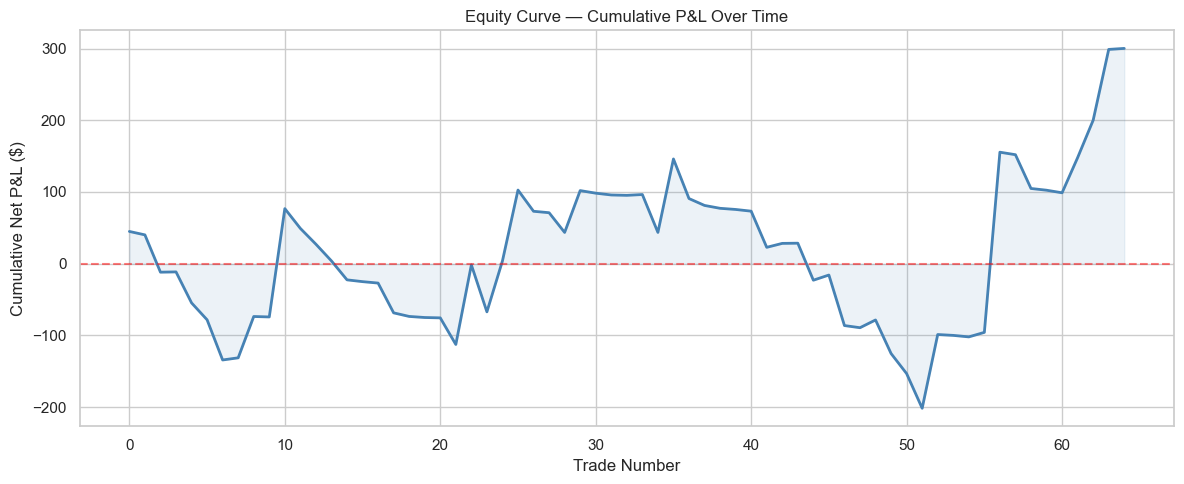

In [4]:
closed_sorted = closed.sort_values('entry_date').reset_index(drop=True)
closed_sorted['cumulative_pnl'] = closed_sorted['net_profit'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(closed_sorted.index, closed_sorted['cumulative_pnl'], 
         color='steelblue', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.fill_between(closed_sorted.index, closed_sorted['cumulative_pnl'], 
                 alpha=0.1, color='steelblue')
plt.title('Equity Curve — Cumulative P&L Over Time')
plt.xlabel('Trade Number')
plt.ylabel('Cumulative Net P&L ($)')
plt.tight_layout()
plt.show()

**Insight:** The equity curve shows three distinct phases — an early drawdown period (trades 
4–10), a choppy mid-section that dips to -$110 around trade 21, and a strong recovery in the 
final phase driven by several large winners. The curve ends at +$300 despite spending a 
significant portion of the period in negative territory, highlighting the importance of 
staying consistent through losing streaks when the R:R ratio is positive.

## Performance by Trade Direction

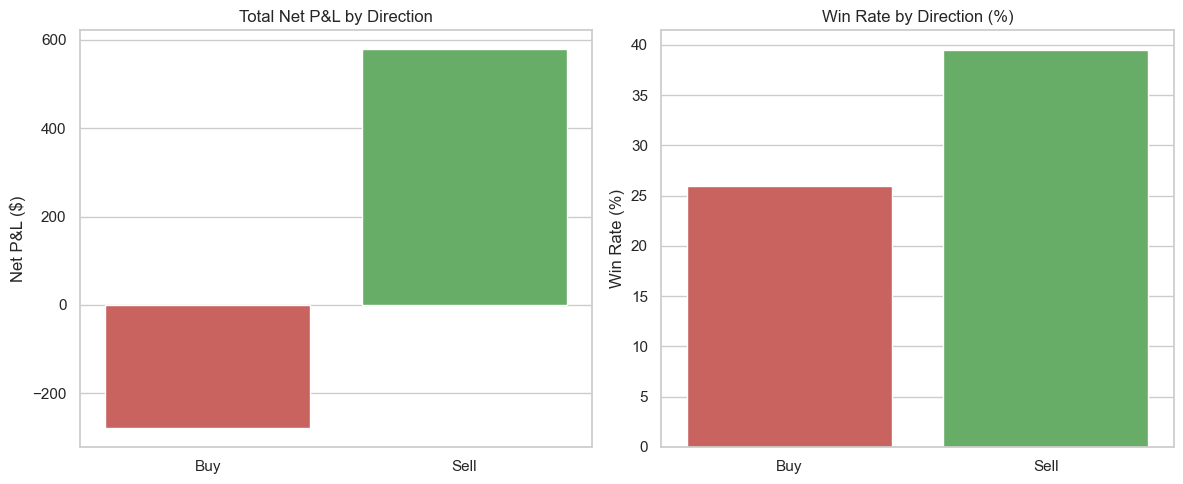

direction  trades  net_pnl  win_rate  avg_profit
      Buy      27  -277.85 25.925926  -10.290741
     Sell      38   578.04 39.473684   15.211579


In [6]:
direction_stats = closed.groupby('direction').agg(
    trades=('net_profit', 'count'),
    net_pnl=('net_profit', 'sum'),
    win_rate=('winner', 'mean'),
    avg_profit=('net_profit', 'mean')
).reset_index()
direction_stats['win_rate'] = direction_stats['win_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=direction_stats, x='direction', y='net_pnl', 
            hue='direction', palette=['#d9534f','#5cb85c'], legend=False, ax=axes[0])
axes[0].set_title('Total Net P&L by Direction')
axes[0].set_ylabel('Net P&L ($)')
axes[0].set_xlabel('')

sns.barplot(data=direction_stats, x='direction', y='win_rate', 
            hue='direction', palette=['#d9534f','#5cb85c'], legend=False, ax=axes[1])
axes[1].set_title('Win Rate by Direction (%)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(direction_stats.to_string(index=False))

**Insight:** The directional bias is striking — Sell trades generated $578 profit at a 39% 
win rate, while Buy trades lost $278 at only 26% win rate. This suggests a clear short bias 
edge in the current market conditions, likely reflecting the bearish EURUSD trend during 
May–June 2026. Buy trades should be taken more selectively or avoided until market 
conditions shift.

## Performance by Exit Reason

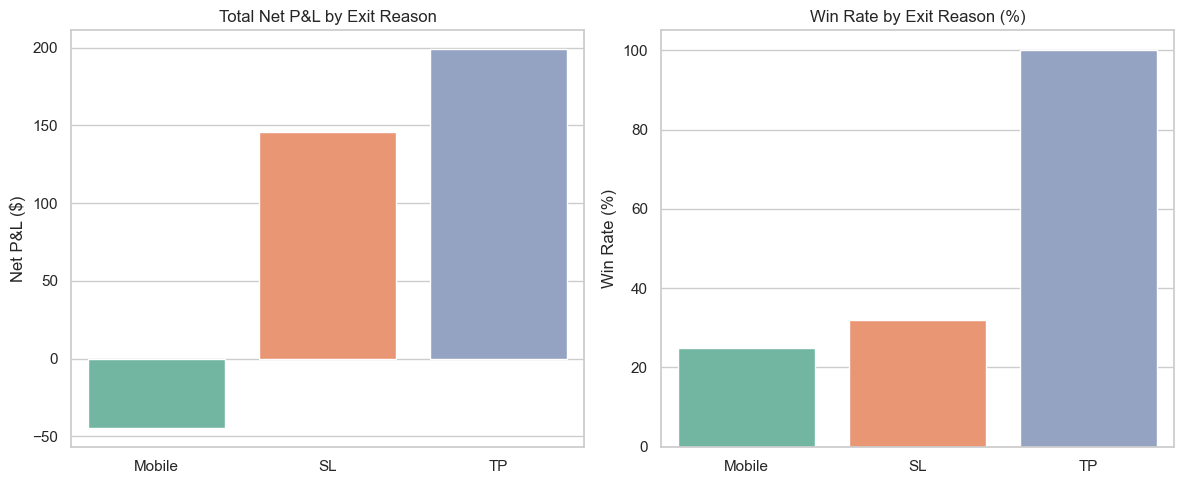

exit_reason  trades  net_pnl  win_rate  avg_profit
     Mobile      12   -44.50      25.0   -3.708333
         SL      50   145.79      32.0    2.915800
         TP       3   198.90     100.0   66.300000


In [7]:
exit_stats = closed.groupby('exit_reason').agg(
    trades=('net_profit', 'count'),
    net_pnl=('net_profit', 'sum'),
    win_rate=('winner', 'mean'),
    avg_profit=('net_profit', 'mean')
).reset_index()
exit_stats['win_rate'] = exit_stats['win_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=exit_stats, x='exit_reason', y='net_pnl',
            hue='exit_reason', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Total Net P&L by Exit Reason')
axes[0].set_ylabel('Net P&L ($)')
axes[0].set_xlabel('')

sns.barplot(data=exit_stats, x='exit_reason', y='win_rate',
            hue='exit_reason', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Win Rate by Exit Reason (%)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(exit_stats.to_string(index=False))

**Insight:** Exit discipline is the single biggest factor in performance. Take profit exits 
(TP) show a 100% win rate averaging $66.30 per trade across 3 trades. Stop loss exits (SL) 
are profitable overall ($145.79) at 32% win rate — the strategy works when levels are 
respected. Manual mobile exits are the weakest category: 25% win rate, -$44.50 net across 
12 trades, averaging -$3.71 per trade. The data is unambiguous — manually closing trades 
early destroys value. Trusting pre-set levels is the highest-impact improvement available.

## Performance by Symbol

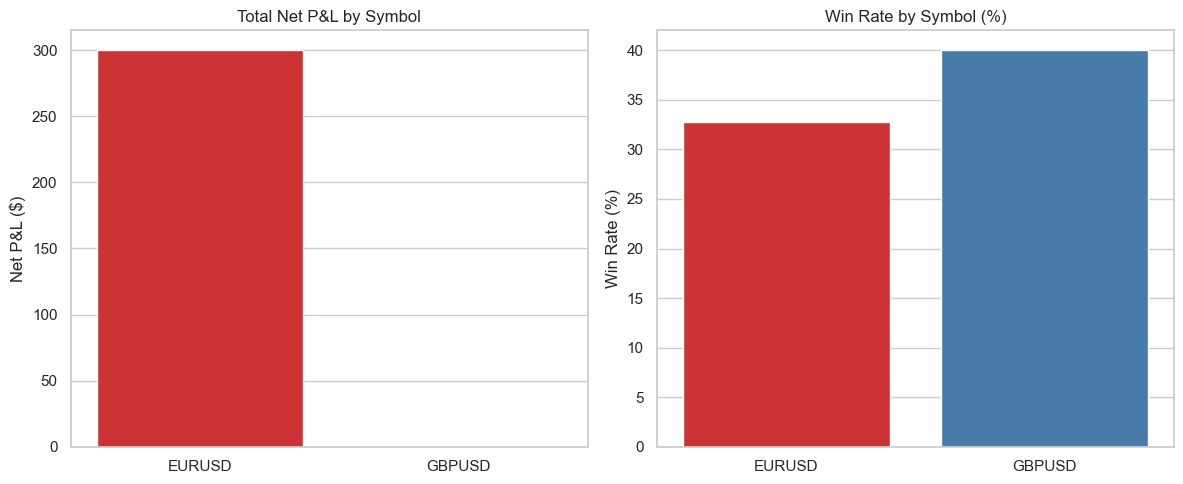

symbol  trades  net_pnl  win_rate  avg_profit
EURUSD      55   299.89 32.727273    5.452545
GBPUSD      10     0.30 40.000000    0.030000


In [8]:
symbol_stats = closed.groupby('symbol').agg(
    trades=('net_profit', 'count'),
    net_pnl=('net_profit', 'sum'),
    win_rate=('winner', 'mean'),
    avg_profit=('net_profit', 'mean')
).reset_index()
symbol_stats['win_rate'] = symbol_stats['win_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=symbol_stats, x='symbol', y='net_pnl',
            hue='symbol', palette='Set1', legend=False, ax=axes[0])
axes[0].set_title('Total Net P&L by Symbol')
axes[0].set_ylabel('Net P&L ($)')
axes[0].set_xlabel('')

sns.barplot(data=symbol_stats, x='symbol', y='win_rate',
            hue='symbol', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title('Win Rate by Symbol (%)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(symbol_stats.to_string(index=False))

**Insight:** Almost all profit comes from EURUSD ($299.89 across 55 trades). GBPUSD shows a 
higher win rate (40%) but is essentially breakeven ($0.30 net across 10 trades), suggesting 
smaller position sizes or less favourable R:R on those trades. EURUSD is clearly the primary 
edge and where focus should remain.

## Trade Duration vs Profitability

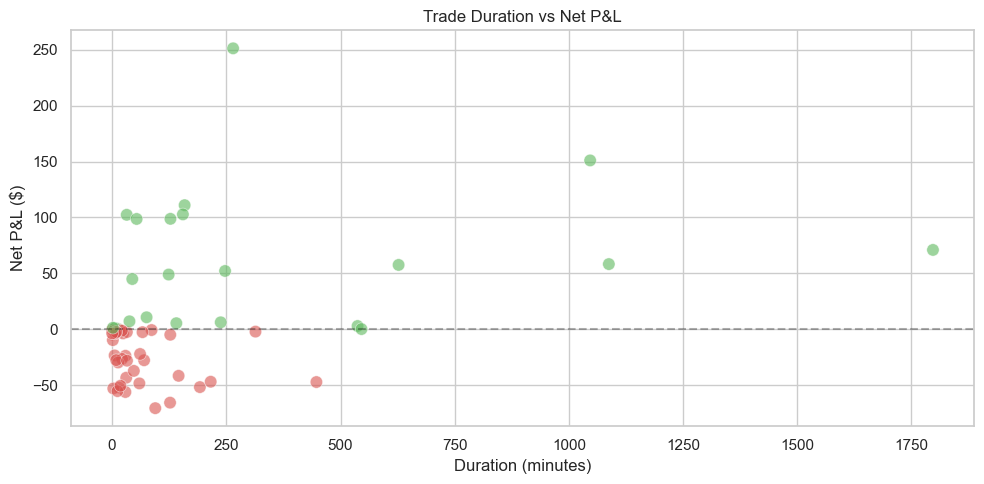

duration_bucket  trades  net_pnl   win_rate
        <30 min      29  -440.50  10.344828
     30-120 min      15   -18.04  33.333333
        2-8 hrs      15   417.50  53.333333
         8+ hrs       6   341.23 100.000000


In [9]:
plt.figure(figsize=(10, 5))
colors = closed['winner'].map({True: '#5cb85c', False: '#d9534f'})
plt.scatter(closed['duration_mins'], closed['net_profit'], 
            c=colors, alpha=0.6, edgecolors='white', linewidth=0.5, s=80)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Trade Duration vs Net P&L')
plt.xlabel('Duration (minutes)')
plt.ylabel('Net P&L ($)')
plt.tight_layout()
plt.show()

# stats by duration bucket
closed['duration_bucket'] = pd.cut(closed['duration_mins'], 
                                    bins=[0, 30, 120, 480, 99999],
                                    labels=['<30 min', '30-120 min', '2-8 hrs', '8+ hrs'])
duration_stats = closed.groupby('duration_bucket', observed=True).agg(
    trades=('net_profit', 'count'),
    net_pnl=('net_profit', 'sum'),
    win_rate=('winner', 'mean')
).reset_index()
duration_stats['win_rate'] = duration_stats['win_rate'] * 100
print(duration_stats.to_string(index=False))

**Insight:** Trade duration is the strongest predictor of profitability in this dataset. 
Trades held under 30 minutes are deeply unprofitable (-$440.50, 10% win rate across 29 trades), 
while trades held 2-8 hours show a 53% win rate (+$417.50) and trades held 8+ hours are 
100% profitable (+$341.23 across 6 trades). This suggests the strategy has a genuine edge 
when given time to play out, but that edge is systematically destroyed by premature exits. 
The single highest-impact change would be to avoid closing trades within the first 30 minutes.

## Summary & Recommendations

Based on analysis of 65 closed trades across EURUSD and GBPUSD (May–June 2026):

**What's working:**
- Overall profitable: +$300.19 net after $93.81 commission
- Strong R:R ratio of 2.55 — strategy design is sound
- Sell bias is correctly aligned with market direction (39% win rate, +$578)
- Longer-duration trades show exceptional performance (100% win rate at 8+ hrs)

**What needs to change:**
1. **Stop manual exits** — mobile closes average -$3.71 per trade vs +$2.92 for SL exits
2. **Avoid sub-30-minute trades** — 29 trades losing $440 is the single biggest drag
3. **Reduce buy-side exposure** — 27 buy trades lost $278; sell trades are the edge
4. **GBPUSD focus** — consider whether 10 near-breakeven trades are worth the commission

**If the three behavioural changes above were applied to this dataset, estimated P&L improvement: ~$500+**